In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

## 1. Cargar el Training Set

In [2]:
# Cargar train.txt (el mismo que usa el entrenamiento)
lists_folder = Path('../data/my-lists')
train_file = lists_folder / 'train.txt'

# Leer el archivo
with open(train_file, 'r') as f:
    lines = f.readlines()

# Parsear filepath y label
data = []
for line in lines:
    parts = line.strip().split()
    filepath = parts[0]
    label = int(parts[1])
    data.append({'filepath': filepath, 'label': label})

train_df = pd.DataFrame(data)

print(f"Total de muestras en training: {len(train_df)}")
print(f"\nDistribución de clases:")
print(train_df['label'].value_counts().sort_index())

Total de muestras en training: 46840

Distribución de clases:
label
0    38239
1     8601
Name: count, dtype: int64


## 2. Calcular Class Weights (Método Actual)

In [3]:
# Calcular class weights usando el mismo método que el código
labels = train_df['label'].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n" + "="*60)
print("📊 CLASS WEIGHTS CALCULADOS")
print("="*60)
print(f"\nClase 0 (Benigno):  {class_weight_dict[0]:.4f}")
print(f"Clase 1 (Maligno):  {class_weight_dict[1]:.4f}")
print(f"\nRatio (Maligno/Benigno): {class_weight_dict[1]/class_weight_dict[0]:.2f}x")
print("\nEsto significa que cada error en un maligno cuenta")
print(f"{class_weight_dict[1]/class_weight_dict[0]:.2f} veces más que un error en un benigno.")
print("="*60)


📊 CLASS WEIGHTS CALCULADOS

Clase 0 (Benigno):  0.6125
Clase 1 (Maligno):  2.7229

Ratio (Maligno/Benigno): 4.45x

Esto significa que cada error en un maligno cuenta
4.45 veces más que un error en un benigno.


## 3. Análisis Detallado

In [4]:
# Contar muestras por clase
n_benign = (train_df['label'] == 0).sum()
n_malignant = (train_df['label'] == 1).sum()
n_total = len(train_df)

# Calcular ratios
ratio_dataset = n_benign / n_malignant
prevalence_malignant = n_malignant / n_total * 100

print("\n📈 ANÁLISIS DEL DATASET")
print("="*60)
print(f"Total de muestras:        {n_total:,}")
print(f"Benignos (clase 0):       {n_benign:,} ({n_benign/n_total*100:.1f}%)")
print(f"Malignos (clase 1):       {n_malignant:,} ({prevalence_malignant:.1f}%)")
print(f"\nRatio de desbalance:      {ratio_dataset:.2f}:1 (benigno:maligno)")
print(f"Prevalencia de malignos:  {prevalence_malignant:.2f}%")
print("="*60)

# Explicar la fórmula
print("\n🔍 FÓRMULA APLICADA")
print("="*60)
print("weight_clase_i = n_total / (n_clases × n_muestras_clase_i)")
print(f"\nPara Benignos:")
print(f"  weight_0 = {n_total} / (2 × {n_benign})")
print(f"  weight_0 = {n_total} / {2 * n_benign}")
print(f"  weight_0 = {class_weight_dict[0]:.4f}")
print(f"\nPara Malignos:")
print(f"  weight_1 = {n_total} / (2 × {n_malignant})")
print(f"  weight_1 = {n_total} / {2 * n_malignant}")
print(f"  weight_1 = {class_weight_dict[1]:.4f}")
print("="*60)


📈 ANÁLISIS DEL DATASET
Total de muestras:        46,840
Benignos (clase 0):       38,239 (81.6%)
Malignos (clase 1):       8,601 (18.4%)

Ratio de desbalance:      4.45:1 (benigno:maligno)
Prevalencia de malignos:  18.36%

🔍 FÓRMULA APLICADA
weight_clase_i = n_total / (n_clases × n_muestras_clase_i)

Para Benignos:
  weight_0 = 46840 / (2 × 38239)
  weight_0 = 46840 / 76478
  weight_0 = 0.6125

Para Malignos:
  weight_1 = 46840 / (2 × 8601)
  weight_1 = 46840 / 17202
  weight_1 = 2.7229


## 4. Visualización

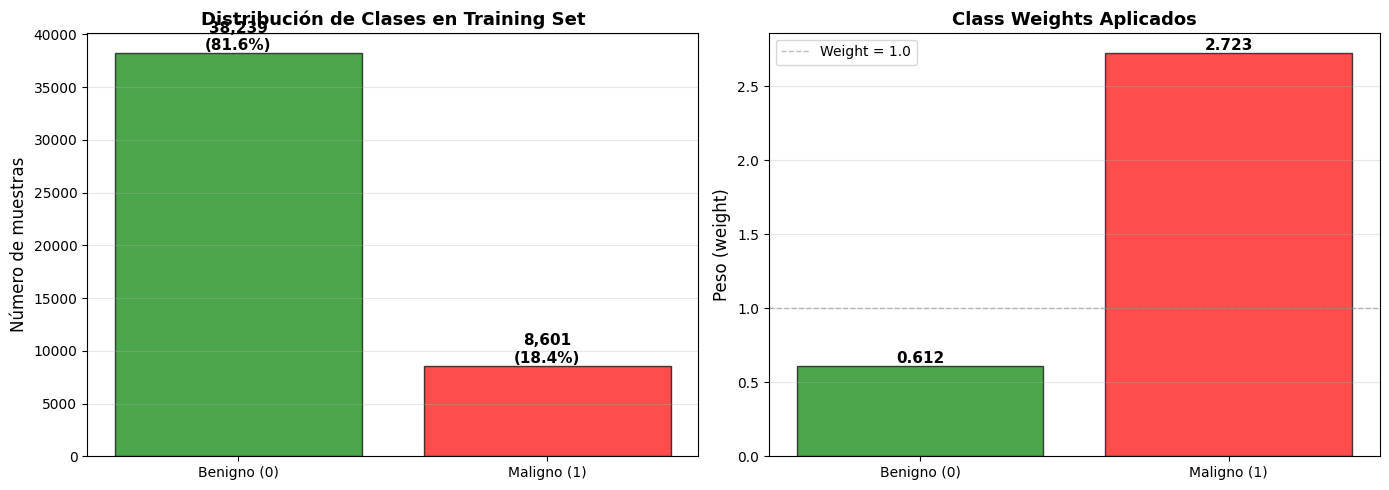


✅ Visualización guardada en: outputs/class_weights_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases
ax1 = axes[0]
classes = ['Benigno (0)', 'Maligno (1)']
counts = [n_benign, n_malignant]
colors = ['green', 'red']

bars1 = ax1.bar(classes, counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Número de muestras', fontsize=12)
ax1.set_title('Distribución de Clases en Training Set', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({count/n_total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Class weights
ax2 = axes[1]
weights = [class_weight_dict[0], class_weight_dict[1]]

bars2 = ax2.bar(classes, weights, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Peso (weight)', fontsize=12)
ax2.set_title('Class Weights Aplicados', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar, weight in zip(bars2, weights):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Añadir línea de referencia en 1.0
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Weight = 1.0')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/class_weights_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualización guardada en: outputs/class_weights_analysis.png")

## 5. Impacto en el Loss

Simulación de cómo afectan los class weights al cálculo del loss.

In [6]:
# Simular un error de clasificación
base_loss = 0.7  # Loss base de Binary Cross-Entropy

loss_benign_weighted = base_loss * class_weight_dict[0]
loss_malignant_weighted = base_loss * class_weight_dict[1]

print("\n⚖️  IMPACTO EN EL LOSS")
print("="*60)
print(f"Asumiendo un loss base de {base_loss} (mismo error en ambos casos):\n")

print(f"Error en BENIGNO:")
print(f"  Loss sin pesos:       {base_loss:.4f}")
print(f"  Loss con class_weight: {loss_benign_weighted:.4f}")
print(f"  Impacto:              {loss_benign_weighted/base_loss:.2f}x\n")

print(f"Error en MALIGNO:")
print(f"  Loss sin pesos:       {base_loss:.4f}")
print(f"  Loss con class_weight: {loss_malignant_weighted:.4f}")
print(f"  Impacto:              {loss_malignant_weighted/base_loss:.2f}x\n")

ratio_impact = loss_malignant_weighted / loss_benign_weighted
print(f"🎯 Un error en maligno PESA {ratio_impact:.2f}x MÁS que un error en benigno")
print("="*60)


⚖️  IMPACTO EN EL LOSS
Asumiendo un loss base de 0.7 (mismo error en ambos casos):

Error en BENIGNO:
  Loss sin pesos:       0.7000
  Loss con class_weight: 0.4287
  Impacto:              0.61x

Error en MALIGNO:
  Loss sin pesos:       0.7000
  Loss con class_weight: 1.9061
  Impacto:              2.72x

🎯 Un error en maligno PESA 4.45x MÁS que un error en benigno


## 6. Resumen Final

In [7]:
print("\n" + "="*60)
print("📋 RESUMEN DE CLASS WEIGHTS")
print("="*60)
print(f"\n✓ Dataset desbalanceado: {ratio_dataset:.1f}:1 (benigno:maligno)")
print(f"✓ Class weights aplicados: {{0: {class_weight_dict[0]:.4f}, 1: {class_weight_dict[1]:.4f}}}")
print(f"✓ Errores en malignos pesan {ratio_impact:.1f}x más")
print(f"\n🎯 Objetivo: Forzar al modelo a prestar más atención a la clase minoritaria")
print(f"           (melanomas) sin necesidad de modificar el dataset.")
print("\n⚠️  Estos pesos se mantienen CONSTANTES durante todo el entrenamiento.")
print("="*60)


📋 RESUMEN DE CLASS WEIGHTS

✓ Dataset desbalanceado: 4.4:1 (benigno:maligno)
✓ Class weights aplicados: {0: 0.6125, 1: 2.7229}
✓ Errores en malignos pesan 4.4x más

🎯 Objetivo: Forzar al modelo a prestar más atención a la clase minoritaria
           (melanomas) sin necesidad de modificar el dataset.

⚠️  Estos pesos se mantienen CONSTANTES durante todo el entrenamiento.
